# **EfficientNet Pre-trained Binary Model with Upsampled Transformed Input**

In this notebook we test a pre-trained EfficientNet model to predict Animal vs Non-animal. <br>
For this, transformed/pre-processed images were used and the class imbalance was fixed. <br>
The transformed images are the ones used on the `02_efficient_net_pretrained_transformations.ipynb`. <br>
The class imbalance was fixed using `label_cropper.py` and `augmenter_routine.ipynb`.

## Libraries

In [1]:
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

In [1]:
# Libraries
import pandas as pd

from deep.constants import ROOT, METADATA_FILE, SEEDS, SCORES
from deep.modelling.model_runs import run_binary_model
from deep.modelling.model_specifications import efficient_net

2025-04-29 01:26:55.153209: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-29 01:26:55.191302: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-29 01:26:55.213741: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-29 01:26:55.220507: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-29 01:26:55.248743: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Setting options
pd.set_option('display.max_rows', None)

## Data Loading

In [3]:
# Load the metadata
data = pd.read_csv(METADATA_FILE)

# Drop unnecessary columns for this problem
data.drop(columns=['phylum', 'family'], inplace=True)

## Data Preprocessing

In [4]:
# Define seeds and path
binary_baseline_path = f"{ROOT}/models/binary_scores.json"

### Clean Images

In [ ]:
# Create transformed images
notebook_path = f'"{ROOT}/notebooks/preprocess_routine/cleaner_routine.ipynb"'
%run $notebook_path

### Upsample Images

In [ ]:
# DISCLAIMER: Ensure you are using 'json_path = UPSAMPLE_JSONS / "oversample_plan_20250427T092327Z.json"'

# Create upsamples images
notebook_path = f'"{ROOT}/notebooks/preprocess_routine/augmenter_routine.ipynb"'
%run $notebook_path

### Resize Images

In [6]:
# Resize images
notebook_path = f'"{ROOT}/notebooks/preprocess_routine/resize_routine.ipynb"'
%run $notebook_path

I0000 00:00:1745884521.020544   22545 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745884521.091320   22545 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745884521.091512   22545 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745884521.092406   22545 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

## Data Modelling

### Raw Model

I0000 00:00:1745886423.288685   24415 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745886423.419932   24415 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745886423.420156   24415 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745886423.421113   24415 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Loaded baseline score: 0.9291174411773682
Found 12453 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 2 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


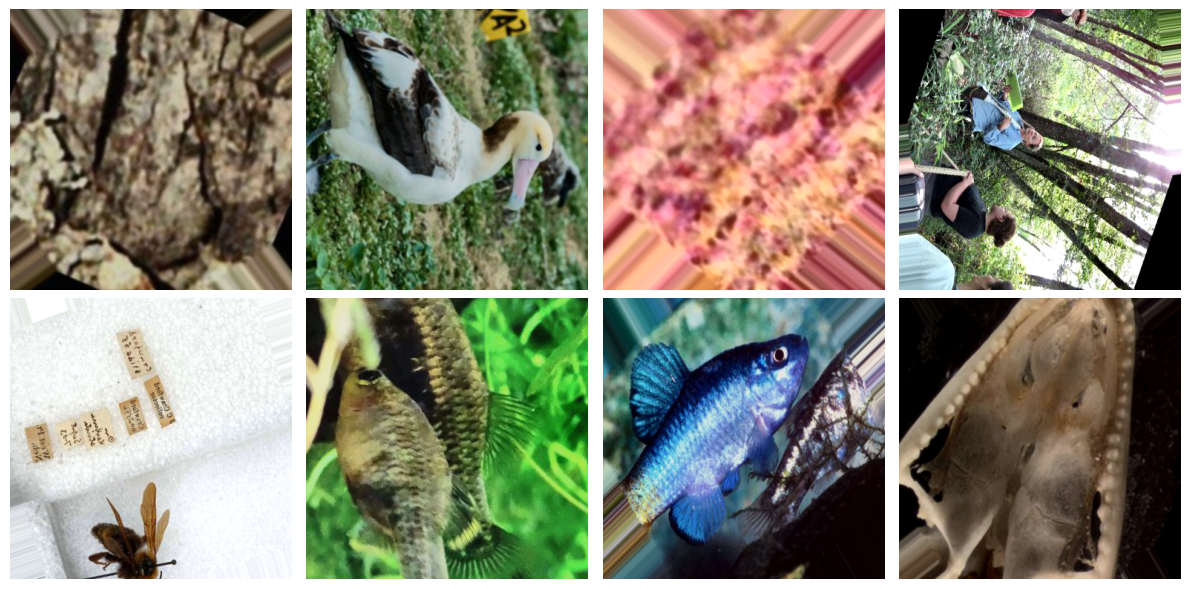

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1745886445.675579   24472 service.cc:146] XLA service 0x749564092010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745886445.675602   24472 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX350, Compute Capability 6.1
2025-04-29 01:27:26.407989: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-29 01:27:28.774396: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90100
2025-04-29 01:27:34.573118: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.34GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-04-29 01:27:37.708330: E external/local_xla/xla/service/slow_operation_alarm.cc:65] 

360/390 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5958 - auc: 0.5695 - loss: 0.6740 - precision: 0.6176 - recall: 0.8952

2025-04-29 01:36:31.045496: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.77GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5965 - auc: 0.5701 - loss: 0.6734 - precision: 0.6171 - recall: 0.9006

2025-04-29 01:38:27.934422: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng42{k2=2,k4=2,k5=0,k6=0,k7=0} for conv (f32[31,24,190,190]{3,2,1,0}, u8[0]{0}) custom-call(f32[31,24,190,190]{3,2,1,0}, f32[24,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=24, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2025-04-29 01:38:28.079043: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.144697153s
Trying algorithm eng42{k2=2,k4=2,k5=0,k6=0,k7=0} for conv (f32[31,24,190,190]{3,2,1,0}, u8[0]{0}) custom-call(f32[31,24,190,190]{3,2,1,0}, f32[24,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=24, custom_ca

390/390 ━━━━━━━━━━━━━━━━━━━━ 703s 2s/step - accuracy: 0.5965 - auc: 0.5702 - loss: 0.6734 - precision: 0.6170 - recall: 0.9007 - val_accuracy: 0.9291 - val_auc: 0.6058 - val_loss: 0.3057 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 613s 2s/step - accuracy: 0.6225 - auc: 0.6593 - loss: 0.6397 - precision: 0.6275 - recall: 0.9288 - val_accuracy: 0.4385 - val_auc: 0.6104 - val_loss: 0.7340 - val_precision: 0.9584 - val_recall: 0.4136 - learning_rate: 0.0010
Epoch 3/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6554 - auc: 0.6974 - loss: 0.6157 - precision: 0.6713 - recall: 0.8481
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
390/390 ━━━━━━━━━━━━━━━━━━━━ 636s 2s/step - accuracy: 0.6555 - auc: 0.6974 - loss: 0.6157 - precision: 0.6713 - recall: 0.8481 - val_accuracy: 0.9305 - val_auc: 0.6130 - val_loss: 0.3191 - val_precision: 0.9304 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/1

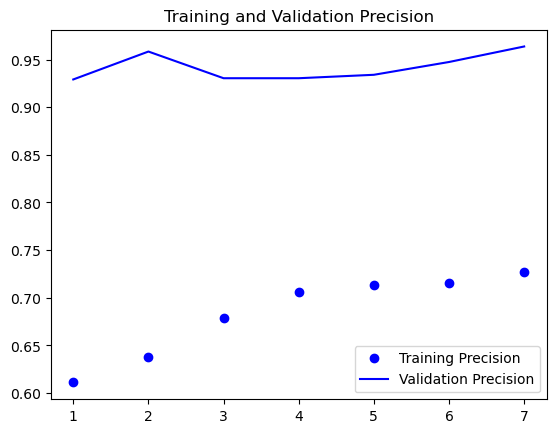

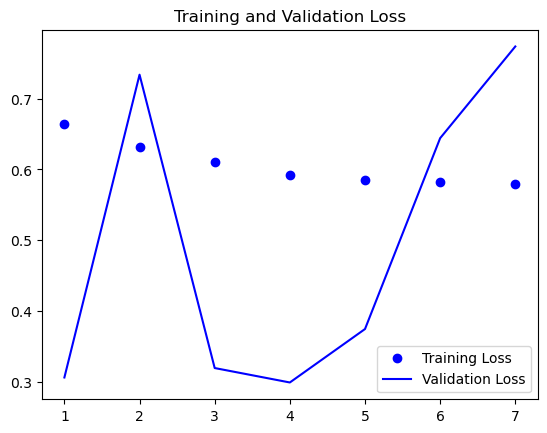

Saved current model as new baseline


In [5]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=False
        ,dropout=False
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='upsampled'
    ,model_name='efficientnetb4'
)

This model using the transformed and upsampled images proved to be underfitting the training data. <br>
We will, however, test if adding regularization and/or the dropout layer will improve the underfitting and the model performance vis the baseline.

### Model with Regularization

In this section we add L2 regularization to our model and test if it improves the model

Loaded baseline score: 0.9304105639457703
Found 12453 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 2 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


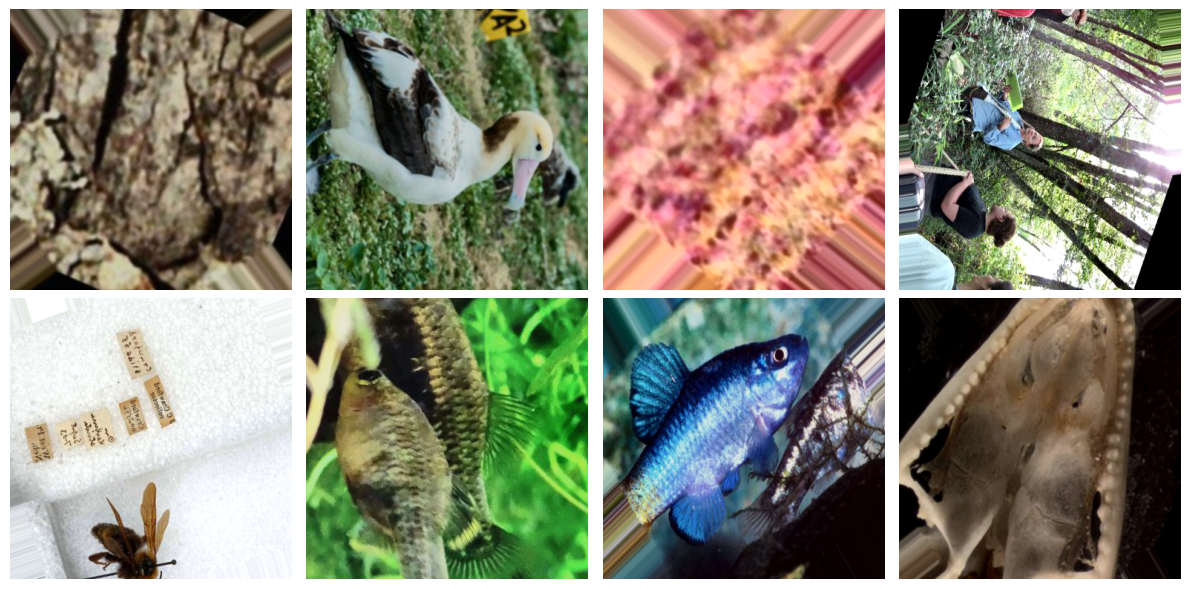

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 699s 2s/step - accuracy: 0.6021 - auc_1: 0.5915 - loss: 0.7439 - precision: 0.6200 - recall: 0.8704 - val_accuracy: 0.9291 - val_auc_1: 0.6035 - val_loss: 0.2616 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 638s 2s/step - accuracy: 0.6249 - auc_1: 0.6524 - loss: 0.6483 - precision: 0.6289 - recall: 0.9466 - val_accuracy: 0.9291 - val_auc_1: 0.6081 - val_loss: 0.2641 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6355 - auc_1: 0.6771 - loss: 0.6322 - precision: 0.6487 - recall: 0.8660
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
390/390 ━━━━━━━━━━━━━━━━━━━━ 651s 2s/step - accuracy: 0.6355 - auc_1: 0.6771 - loss: 0.6322 - precision: 0.6487 - recall: 0.8661 - val_accuracy: 0.3489 - val_auc_1: 0.6085 - val_loss: 0.8779 - val_precision: 0.9630 - val_recall: 0.3111 - learni

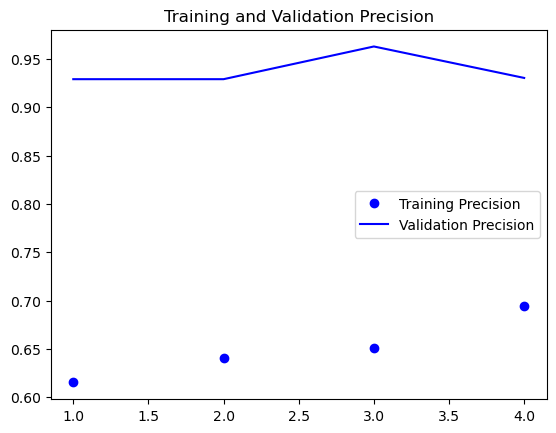

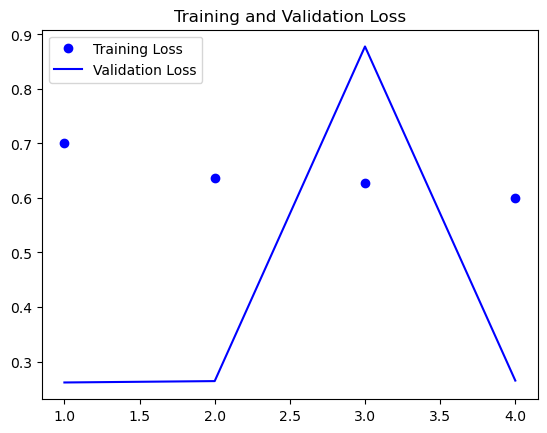

Current model not better than baseline


In [6]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=True
        ,dropout=False
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='upsampled'
    ,model_name='efficientnetb4'
)

Regularization did not improve the model.

### Model with Dropout

In this section we add a dropout layer to the model and test if it improves the results.

Loaded baseline score: 0.9304105639457703
Found 12453 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 2 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


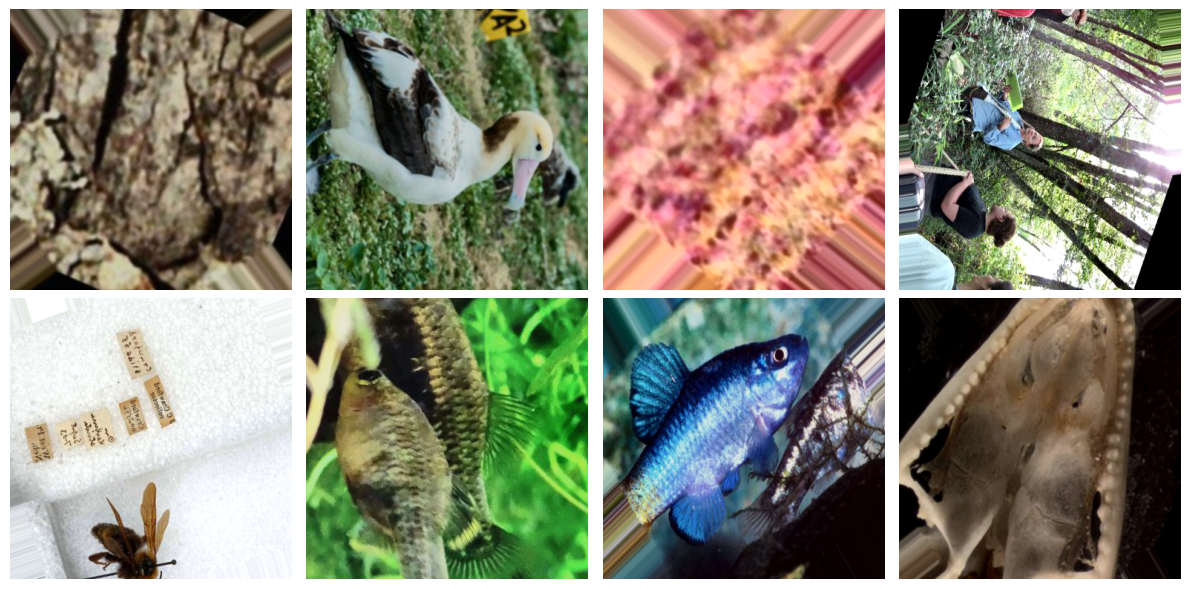

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 724s 2s/step - accuracy: 0.5839 - auc_2: 0.5475 - loss: 0.6966 - precision: 0.6177 - recall: 0.8321 - val_accuracy: 0.0709 - val_auc_2: 0.6024 - val_loss: 1.2014 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 660s 2s/step - accuracy: 0.6033 - auc_2: 0.5611 - loss: 0.6648 - precision: 0.6064 - recall: 0.9711 - val_accuracy: 0.9291 - val_auc_2: 0.6048 - val_loss: 0.2636 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 669s 2s/step - accuracy: 0.6263 - auc_2: 0.6395 - loss: 0.6427 - precision: 0.6328 - recall: 0.9172 - val_accuracy: 0.9291 - val_auc_2: 0.6111 - val_loss: 0.2789 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6318 - auc_2: 0.6258 - loss: 0.6425 - precision: 0.6358 - recall: 0.9178
Epoch 4: ReduceLROnPlateau reducing learn

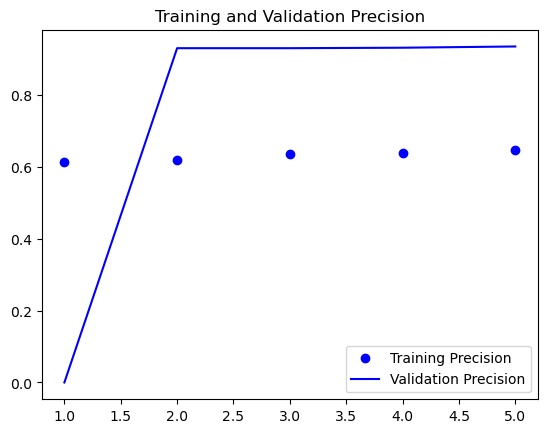

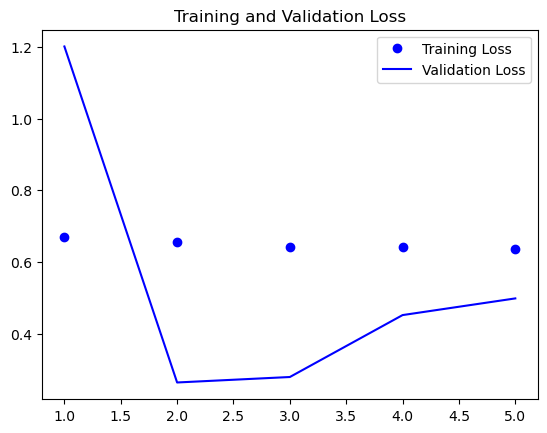

Current model not better than baseline


In [7]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=False
        ,dropout=True
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='upsampled'
    ,model_name='efficientnetb4'
)

The dropout layer did not improve the model.

Now, we will attempt to fix the class imbalance based on the transformed images and recheck the model.